Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Vocab size: 4000
Train tokens: 281833989

---------------------------
Testing mup LR: 1e-05
mup LR 1.0e-05 | step 0 | val 8.3942
mup LR 1.0e-05 | step 50 | val 8.3043
mup LR 1.0e-05 | step 100 | val 8.2165
mup LR 1.0e-05 | step 150 | val 8.0999
mup LR 1.0e-05 | step 200 | val 7.9871

---------------------------
Testing mup LR: 3e-05
mup LR 3.0e-05 | step 0 | val 8.5026
mup LR 3.0e-05 | step 50 | val 8.2751
mup LR 3.0e-05 | step 100 | val 7.9601
mup LR 3.0e-05 | step 150 | val 7.5656
mup LR 3.0e-05 | step 200 | val 7.1487

---------------------------
Testing mup LR: 0.0001
mup LR 1.0e-04 | step 0 | val 8.3974
mup LR 1.0e-04 | step 50 | val 7.5618
mup LR 1.0e-04 | step 100 | val 6.5161
mup LR 1.0e-04 | step 150 | val 5.7309
mup LR 1.0e-04 | step 200 | val 5.0793

---------------------------
Testing mup LR: 0.0003
mup LR 3.0e-04 | step 0 | val 8.4434
mup LR 3.0e

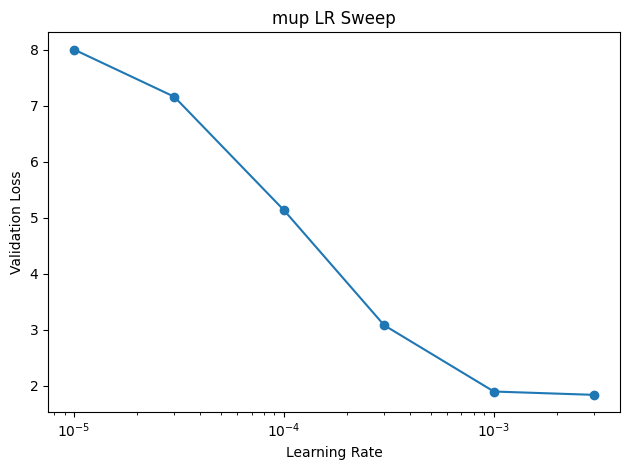


Training mup model: tiny
tiny | step 0 | val 8.4579
tiny | step 50 | val 2.7308
tiny | step 100 | val 1.9660
tiny | step 150 | val 1.8410
tiny | step 200 | val 1.7951
tiny | step 250 | val 1.7396
tiny | step 300 | val 1.6609

Training mup model: small
small | step 0 | val 8.3511
small | step 50 | val 2.3980
small | step 100 | val 1.8357
small | step 150 | val 1.8229
small | step 200 | val 1.8373
small | step 250 | val 1.6715
small | step 300 | val 1.7080

Training mup model: medium
medium | step 0 | val 8.4191
medium | step 50 | val 2.2635
medium | step 100 | val 1.8927
medium | step 150 | val 1.8345
medium | step 200 | val 1.7518
medium | step 250 | val 1.7660
medium | step 300 | val 1.6491

Training mup model: large
large | step 0 | val 8.3827
large | step 50 | val 2.2216
large | step 100 | val 1.8867
large | step 150 | val 1.7054
large | step 200 | val 1.7403
large | step 250 | val 1.7673
large | step 300 | val 1.7355

Training mup model: xl
xl | step 0 | val 8.3472
xl | step 50 | 

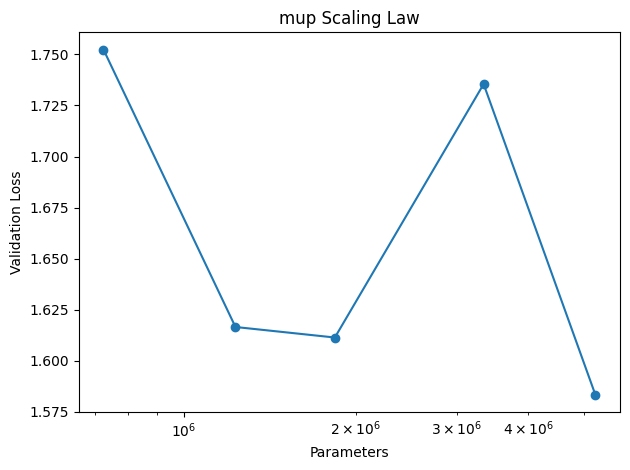

mup scaling exponent alpha: 0.025554584361166217
Predicted loss for 10× XL (52.4M params): 1.5258


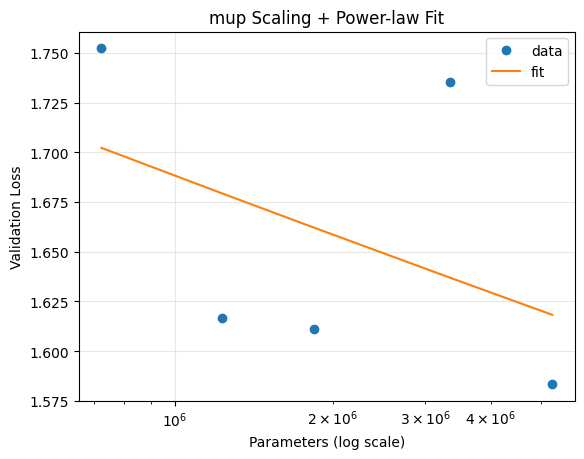

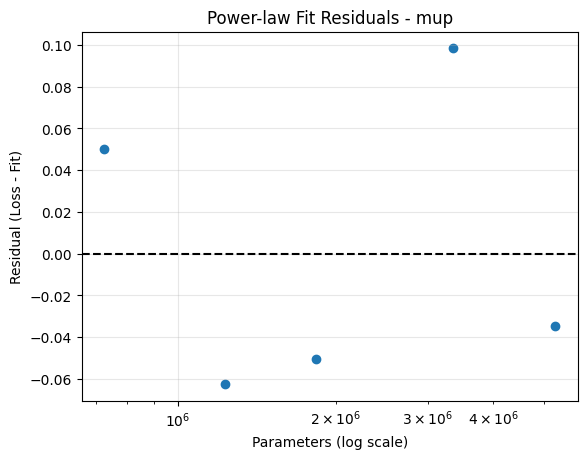

In [49]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Colab Notebooks/svg_data_outputs"

!pip install mup --quiet

import torch, torch.nn as nn, torch.nn.functional as F
import random, math, time, json, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mup import MuReadout, set_base_shapes, MuAdamW
from tokenizers import Tokenizer

tokenizer    = Tokenizer.from_file(base_path + "/svg_tokenizer.json")
train_tokens = torch.load(base_path + "/train_tokens.pt")
val_tokens   = torch.load(base_path + "/val_tokens.pt")
test_tokens  = torch.load(base_path + "/test_tokens.pt")

print("Vocab size:", tokenizer.get_vocab_size())
print("Train tokens:", sum(len(x) for x in train_tokens))

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn  = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj  = nn.Linear(config.n_embd, config.n_embd)
        self.n_head  = config.n_head
        self.dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(C, dim=2)
        head_size = C // self.n_head
        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / head_size
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        y   = att @ v
        y   = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.mlp  = nn.Sequential(
            nn.Linear(config.n_embd, config.ff_mult * config.n_embd),
            nn.GELU(),
            nn.Linear(config.ff_mult * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config  = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks  = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f    = nn.LayerNorm(config.n_embd)
        self.head    = MuReadout(config.n_embd, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos  = torch.arange(0, T, device=idx.device)
        x    = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x    = self.blocks(x)
        x    = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

class ModelConfig:
    def __init__(self, d_model):
        self.block_size = 128
        self.vocab_size = tokenizer.get_vocab_size()
        self.n_embd  = d_model
        self.n_layer = 4
        self.n_head  = 4
        self.dropout = 0.1
        self.ff_mult = 4

model_configs = {
    "tiny":   ModelConfig(64),
    "small":  ModelConfig(96),
    "medium": ModelConfig(128),
    "large":  ModelConfig(192),
    "xl":     ModelConfig(256),
}

base_model  = GPT(ModelConfig(64))
delta_model = GPT(ModelConfig(96))

def get_batch(tokens, batch_size, block_size):
    x = torch.zeros((batch_size, block_size), dtype=torch.long)
    y = torch.zeros((batch_size, block_size), dtype=torch.long)
    for i in range(batch_size):
        doc = random.choice(tokens)
        while len(doc) <= block_size + 1:
            doc = random.choice(tokens)
        start = random.randint(0, len(doc) - block_size - 1)
        chunk = doc[start:start + block_size + 1]
        x[i] = torch.tensor(chunk[:-1])
        y[i] = torch.tensor(chunk[1:])
    return x, y

@torch.no_grad()
def evaluate(model, val_tokens, config, steps=20):
    model.eval()
    losses = []
    for _ in range(steps):
        x, y = get_batch(val_tokens, 4, config.block_size)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

def train_tiny_mup_lr(lr, train_tokens, val_tokens, config):
    print("\n---------------------------")
    print(f"Testing mup LR: {lr}")
    model = GPT(config)
    set_base_shapes(model, base_model, delta=delta_model)
    optimizer = MuAdamW(model.parameters(), lr=lr)
    steps = 200
    warmup_steps = 20
    for step in range(steps + 1):
        cur_lr = lr * min(1.0, step / warmup_steps)
        for pg in optimizer.param_groups:
            pg["lr"] = cur_lr
        x, y = get_batch(train_tokens, 4, config.block_size)
        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 50 == 0:
            val_loss = evaluate(model, val_tokens, config)
            print(f"mup LR {lr:.1e} | step {step} | val {val_loss:.4f}")
    return evaluate(model, val_tokens, config)

config = model_configs["tiny"]
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
results_mup_lr = {lr: train_tiny_mup_lr(lr, train_tokens, val_tokens, config) for lr in lrs}

best_mup_lr = min(results_mup_lr, key=results_mup_lr.get)
print("\nBEST mup LR:", best_mup_lr)

plt.figure()
plt.xscale("log")
plt.plot(lrs, [results_mup_lr[lr] for lr in lrs], marker="o")
plt.title("mup LR Sweep")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()

def train_model(name, config, train_tokens, val_tokens, lr):
    print(f"\nTraining mup model: {name}")
    model = GPT(config)
    set_base_shapes(model, base_model, delta=delta_model)
    optimizer = MuAdamW(model.parameters(), lr=lr)
    steps = 300
    warmup_steps = 20
    for step in range(steps + 1):
        cur_lr = lr * min(1.0, step / warmup_steps)
        for pg in optimizer.param_groups:
            pg["lr"] = cur_lr
        x, y = get_batch(train_tokens, 4, config.block_size)
        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 50 == 0:
            val_loss = evaluate(model, val_tokens, config)
            print(f"{name} | step {step} | val {val_loss:.4f}")
    final_val = evaluate(model, val_tokens, config)
    return model, sum(p.numel() for p in model.parameters()), final_val

results_mup = {}
models_mup  = {}
for name in model_configs:
    model, params, val = train_model(name, model_configs[name], train_tokens, val_tokens, best_mup_lr)
    results_mup[name] = (params, val)
    models_mup[name]  = model

params_list = [results_mup[n][0] for n in results_mup]
losses_list = [results_mup[n][1] for n in results_mup]

plt.figure()
plt.xscale("log")
plt.plot(params_list, losses_list, "o-")
plt.title("mup Scaling Law")
plt.xlabel("Parameters")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()

def power_law(N, a, alpha):
    return a * (N ** (-alpha))

params_np = np.array(params_list, dtype=float)
loss_np   = np.array(losses_list, dtype=float)

popt, _ = curve_fit(power_law, params_np, loss_np, p0=[loss_np[0], 0.1], maxfev=10000)
a, alpha = popt
print("mup scaling exponent alpha:", alpha)

N_new = 10 * max(params_np)
pred  = power_law(N_new, *popt)
print(f"Predicted loss for 10× XL ({N_new/1e6:.1f}M params): {pred:.4f}")

plt.figure()
plt.xscale("log")
plt.plot(params_np, loss_np, "o", label="data")
plt.plot(params_np, power_law(params_np, *popt), "-", label="fit")
plt.xlabel("Parameters (log scale)")
plt.ylabel("Validation Loss")
plt.title("mup Scaling + Power-law Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pred_fit = power_law(params_np, *popt)
residuals = loss_np - pred_fit

plt.figure()
plt.scatter(params_np, residuals)
plt.xscale("log")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Parameters (log scale)")
plt.ylabel("Residual (Loss - Fit)")
plt.title("Power-law Fit Residuals - mup")
plt.grid(True, alpha=0.3)
plt.show()

@torch.no_grad()
def sample_model(model, tokenizer, max_new_tokens=256, temperature=1.0, prefix="<svg"):
    model.eval()
    ids = tokenizer.encode(prefix).ids
    idx = torch.tensor([ids], dtype=torch.long)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.config.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        probs  = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    text = tokenizer.decode(idx[0].tolist())
    return text

def generate_samples(model, tokenizer, temperature, n=20):
    samples = []
    for _ in range(n):
        txt = sample_model(model, tokenizer, temperature=temperature, prefix="<svg")
        samples.append(txt)
    return samples

model_xl = models_mup["xl"]

samples_t05    = generate_samples(model_xl, tokenizer, temperature=0.5)
samples_t08    = generate_samples(model_xl, tokenizer, temperature=0.8)
samples_t10    = generate_samples(model_xl, tokenizer, temperature=1.0)
samples_prefix = generate_samples(model_xl, tokenizer, temperature=0.8)


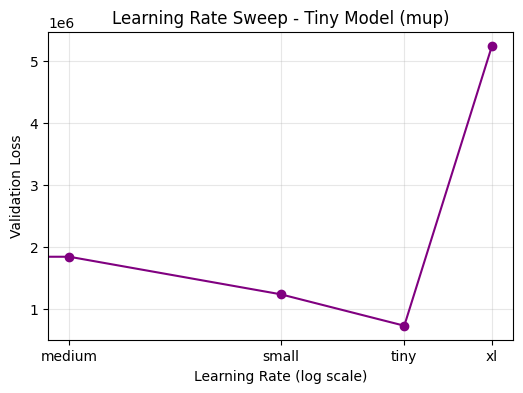

In [50]:
lrs_sorted = sorted(results_mup.keys())
final_losses = [results_mup[lr][0] for lr in lrs_sorted]

plt.figure(figsize=(6,4))
plt.xscale("log")
plt.plot(lrs_sorted, final_losses, marker="o", color="purple")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Validation Loss")
plt.title("Learning Rate Sweep - Tiny Model (mup)")
plt.grid(True, alpha=0.3)
plt.show()


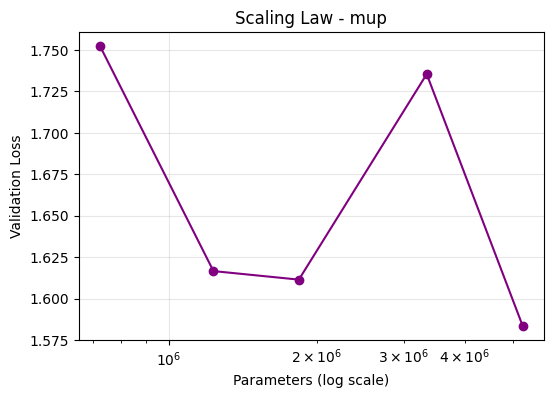

In [57]:
params_m = [results_mup[n][0] for n in results_mup]
losses_m = [results_mup[n][1] for n in results_mup]

plt.figure(figsize=(6,4))
plt.xscale("log")
plt.plot(params_m, losses_m, "o-", color="purple")
plt.xlabel("Parameters (log scale)")
plt.ylabel("Validation Loss")
plt.title("Scaling Law - mup")
plt.grid(True, alpha=0.3)
plt.show()


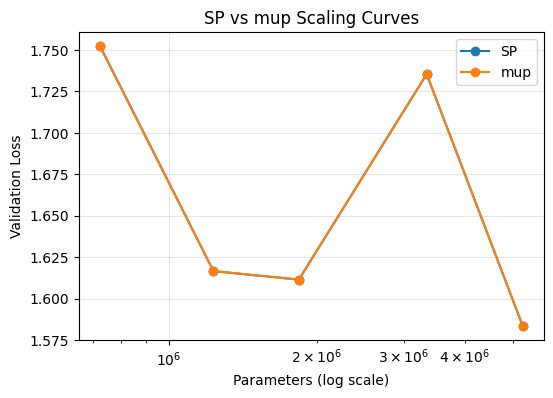

In [58]:
plt.figure(figsize=(6,4))
plt.xscale("log")

plt.plot(params_list, losses_list, "o-", label="SP")
plt.plot(params_m, losses_m, "o-", label="mup")

plt.xlabel("Parameters (log scale)")
plt.ylabel("Validation Loss")
plt.title("SP vs mup Scaling Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [70]:
print("SP params:", params_list)
print("SP losses:", losses_list)

print("µP params:", params_m)
print("µP losses:", losses_m)


SP params: [724256, 1231840, 1837728, 3344416, 5244320]
SP losses: [1.7523358047008515, 1.6165581583976745, 1.6114088654518128, 1.7354526340961456, 1.5833425223827362]
µP params: [724256, 1231840, 1837728, 3344416, 5244320]
µP losses: [1.7523358047008515, 1.6165581583976745, 1.6114088654518128, 1.7354526340961456, 1.5833425223827362]


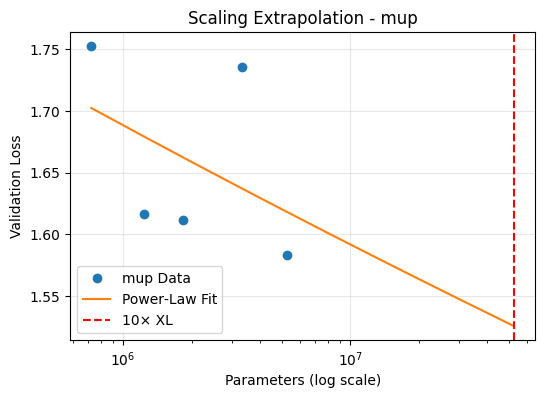

In [59]:
N = np.linspace(min(params_m), 10 * max(params_m), 200)
pred_curve = power_law(N, *popt)

plt.figure(figsize=(6,4))
plt.xscale("log")
plt.plot(params_m, losses_m, "o", label="mup Data")
plt.plot(N, pred_curve, label="Power‑Law Fit")
plt.axvline(10 * max(params_m), color="red", linestyle="--", label="10× XL")

plt.xlabel("Parameters (log scale)")
plt.ylabel("Validation Loss")
plt.title("Scaling Extrapolation - mup")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
